In [ ]:
import os
import shutil

if not os.path.exists('/content'):
    !mkdir -p /content

if os.path.exists('/content/InstantMesh'):
    shutil.rmtree('/content/InstantMesh')

%cd /content
!GIT_LFS_SKIP_SMUDGE=1 git clone -b Vic https://github.com/SihamDaanouni/InstantMesh.git

!pip install git+https://github.com/CompVis/taming-transformers.git


%cd /content/InstantMesh

In [ ]:
import os
import shutil


if not os.path.exists('/content'):
    !mkdir -p /content


%cd /content
if os.path.exists('/content/SyncDreamer'):
    shutil.rmtree('/content/SyncDreamer')
!GIT_LFS_SKIP_SMUDGE=1 git clone https://github.com/liuyuan-pal/SyncDreamer


!pip install -q git+https://github.com/CompVis/taming-transformers.git

!pip install -r "/content/SyncDreamer/requirements.txt"

!pip install -q "numpy<2.0.0"
!pip install -q onnxruntime-gpu ninja
!pip install -q PyMCubes trimesh rembg xatlas plyfile imageio[ffmpeg]

!pip install -q pytorch-lightning==2.1.2 gradio==3.50.2 einops omegaconf torchmetrics webdataset accelerate tensorboard

os.environ['CUDA_HOME'] = '/usr/local/cuda'

os.environ['PATH'] = os.environ.get('PATH', '') + ':/usr/local/cuda/bin'


%cd /content
if os.path.exists('/content/nvdiffrast'):
    shutil.rmtree('/content/nvdiffrast')
!git clone https://github.com/NVlabs/nvdiffrast.git
%cd /content/nvdiffrast
!pip install -q --no-build-isolation .


!pip install -q "cupy-cuda12x<14.0.0"
!pip install -q peft==0.10.0

%cd /content/InstantMesh
print("\n=== INSTALLATION TERMINÉE ===")
print("Branche active :", end=" ")
!git branch --show-current

In [ ]:

!pip install -q gdown
import gdown
import urllib.request
import os
import requests

output_dir = "/content/InstantMesh/ckpt"
os.makedirs(output_dir, exist_ok=True)


SYNCDREAM_URL = "https://drive.google.com/uc?id=1ypyD5WXxAnsWjnHgAfOAGolV0Zd9kpam"
output_sync = os.path.join(output_dir, "syncdreamer-pretrain.ckpt")


SYNCDREAM_URL = "https://drive.google.com/uc?id=1ypyD5WXxAnsWjnHgAfOAGolV0Zd9kpam"
SYNCDREAM_KAGGLE = "https://huggingface.co/camenduru/SyncDreamer/resolve/main/syncdreamer-pretrain.ckpt"
output = os.path.join(output_dir, "syncdreamer-pretrain.ckpt")
response = requests.get(SYNCDREAM_KAGGLE, stream=True)
response.raise_for_status()

with open(output, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)
# On ne télécharge que si le fichier n'existe pas déjà (pour gagner du temps)
#if not os.path.exists(output_sync):
#    gdown.download(SYNCDREAM_URL, output_sync, quiet=False)

# VIT L 14
VITL14_URL = "https://openaipublic.azureedge.net/clip/models/b8cca3fd41ae0c99ba7e8951adf17d267cdb84cd88be6f7c2e0eca1737a03836/ViT-L-14.pt"
output_vit = os.path.join(output_dir, "ViT-L-14.pt")

if not os.path.exists(output_vit):
    urllib.request.urlretrieve(VITL14_URL, output_vit)

print(f"Vérification : {os.listdir(output_dir)}")

In [ ]:
import sys
import site
from importlib import reload

sys.path.append('/usr/local/lib/python3.12/dist-packages')
sys.path.append('/content/SyncDreamer')

In [ ]:
import os
import shutil

target_dir = "/content/SyncDreamer/ckpt"
os.makedirs(target_dir, exist_ok=True)

source_dir = "/content/InstantMesh/ckpt"

if os.path.exists(source_dir):
    for file in os.listdir(source_dir):
        shutil.move(os.path.join(source_dir, file), os.path.join(target_dir, file))
    print(f"Fichiers déplacés vers {target_dir}")
else:
    print("Le dossier source n'a pas été trouvé. Vérification manuelle...")

if os.path.exists(os.path.join(target_dir, "syncdreamer-pretrain.ckpt")):
    print("SUCCÈS : syncdreamer-pretrain.ckpt est au bon endroit !")
else:
    print("ERREUR : Le fichier est toujours introuvable. Relance la cellule de téléchargement.")

!ln -s /content/SyncDreamer/ckpt /content/InstantMesh/ckpt 2>/dev/null

In [ ]:
!pip install taming-transformers-rom1504

In [ ]:
!pip uninstall -y clip
!pip install git+https://github.com/openai/CLIP.git

In [ ]:
!pip install transformers==4.44.2 

In [ ]:
!pip install peft==0.17.0

In [ ]:
def executer_inference_3d(filename="/content/InstantMesh/examples/hatsune_miku.png", model_type="zero123plus_finetuned"):
    """
    Lance l'inférence InstantMesh pour une image spécifique.
    Arguments:
        filename : le nom du fichier sans extension
        model_type : le modèle de diffusion à utiliser
    """
    # Configuration des chemins
    lib_path = "/usr/local/lib/python3.12/dist-packages"
    input_path = f"{filename}"
    config_path = "configs/instant-mesh-base.yaml"
    
    print(f"--- Lancement de l'inférence ---")
    print(f"Fichier : {input_path}")
    print(f"Modèle : {model_type}")

    # Changement de répertoire
    %cd /content/InstantMesh

    # Exécution de la commande shell via l'interpolation de variables
    !PYTHONPATH={lib_path}:/content/SyncDreamer python run.py \
        {config_path} \
        {input_path} \
        --save_video \
        --diffusion_model {model_type}



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Video
import os


FILENAME = "hatsune_miku"

def comparer_modeles_3d(filename=FILENAME):
    """
    Compare les images multi-vues et les vidéos de trois modèles différents.
    """

    paths = {
        "Original (fine-tuned)": f"outputs/instant-mesh-base_zero123plus_finetuned/images/{filename}.png",
        "Option A (Zero123+ Base)": f"outputs/instant-mesh-base_zero123plus_base/images/{filename}.png",
        "Option B (SyncDreamer)": f"/content/InstantMesh/outputs/instant-mesh-base_syncdreamer/images/{filename}_syncdreamer_grid.png",
    }

    video_paths = {
        "Original (Fine-tuned)": f"outputs/instant-mesh-base_zero123plus_finetuned/videos/{filename}.mp4",
        "Option A (Base)": f"outputs/instant-mesh-base_zero123plus_base/videos/{filename}.mp4",
        "Option B (SyncDreamer)": f"/content/InstantMesh/outputs/instant-mesh-base_syncdreamer/videos/{filename}.mp4",
    }

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    for ax, (label, path) in zip(axes, paths.items()):
        if os.path.exists(path):
            ax.imshow(np.array(Image.open(path)))
            ax.set_title(label, fontsize=14, fontweight='bold')
        else:
            ax.set_title(f"!!! FICHIER MANQUANT !!!\n{os.path.basename(path)}", color='red', fontsize=10)
            print(f"Attention : Image absente -> {path}")
        ax.axis('off')
    
    plt.suptitle("Comparaison des vues générées (3 Modèles)", fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    os.makedirs('outputs/comparaisons', exist_ok=True)
    plt.savefig('outputs/comparaisons/comparaison_3_modeles.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n--- AFFICHAGE DES VIDÉOS POUR : {filename} ---")
    for label, path in video_paths.items():
        if os.path.exists(path):
            print(f"\n[OK] Modèle : {label}")
            display(Video(path, embed=True, width=512))
        else:
            print(f"[X] Vidéo manquante pour {label} : {path}")



Processing: Vtech_Cruise_Learn_Car_25_Years.zip


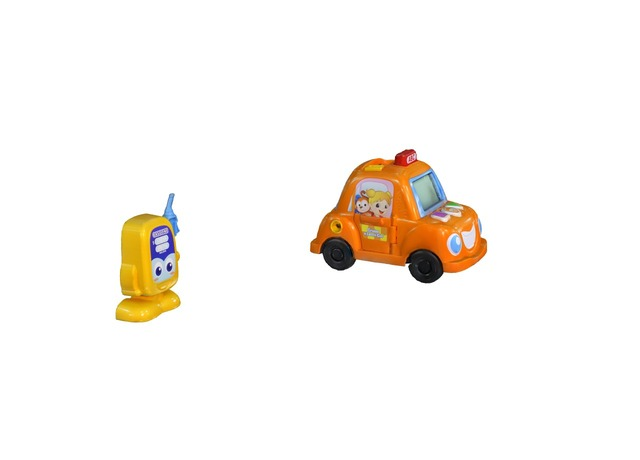

--- Lancement de l'inférence ---
Fichier : preview/Vtech_Cruise_Learn_Car_25_Years/Vtech_Cruise_Learn_Car_25_Years.jpg
Modèle : zero123plus_finetuned
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : preview/Vtech_Cruise_Learn_Car_25_Years/Vtech_Cruise_Learn_Car_25_Years.jpg
Modèle : zero123plus_base
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : /content/preview/Vtech_Cruise_Learn_Car_25_Years/Vtech_Cruise_Learn_Car_25_Years.jpg
Modèle : syncdreamer
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
Attention : Image absente -> outputs/instant-mesh-base_zero123plus_finetuned/images/Vtech_Cruise_Learn_Car_25

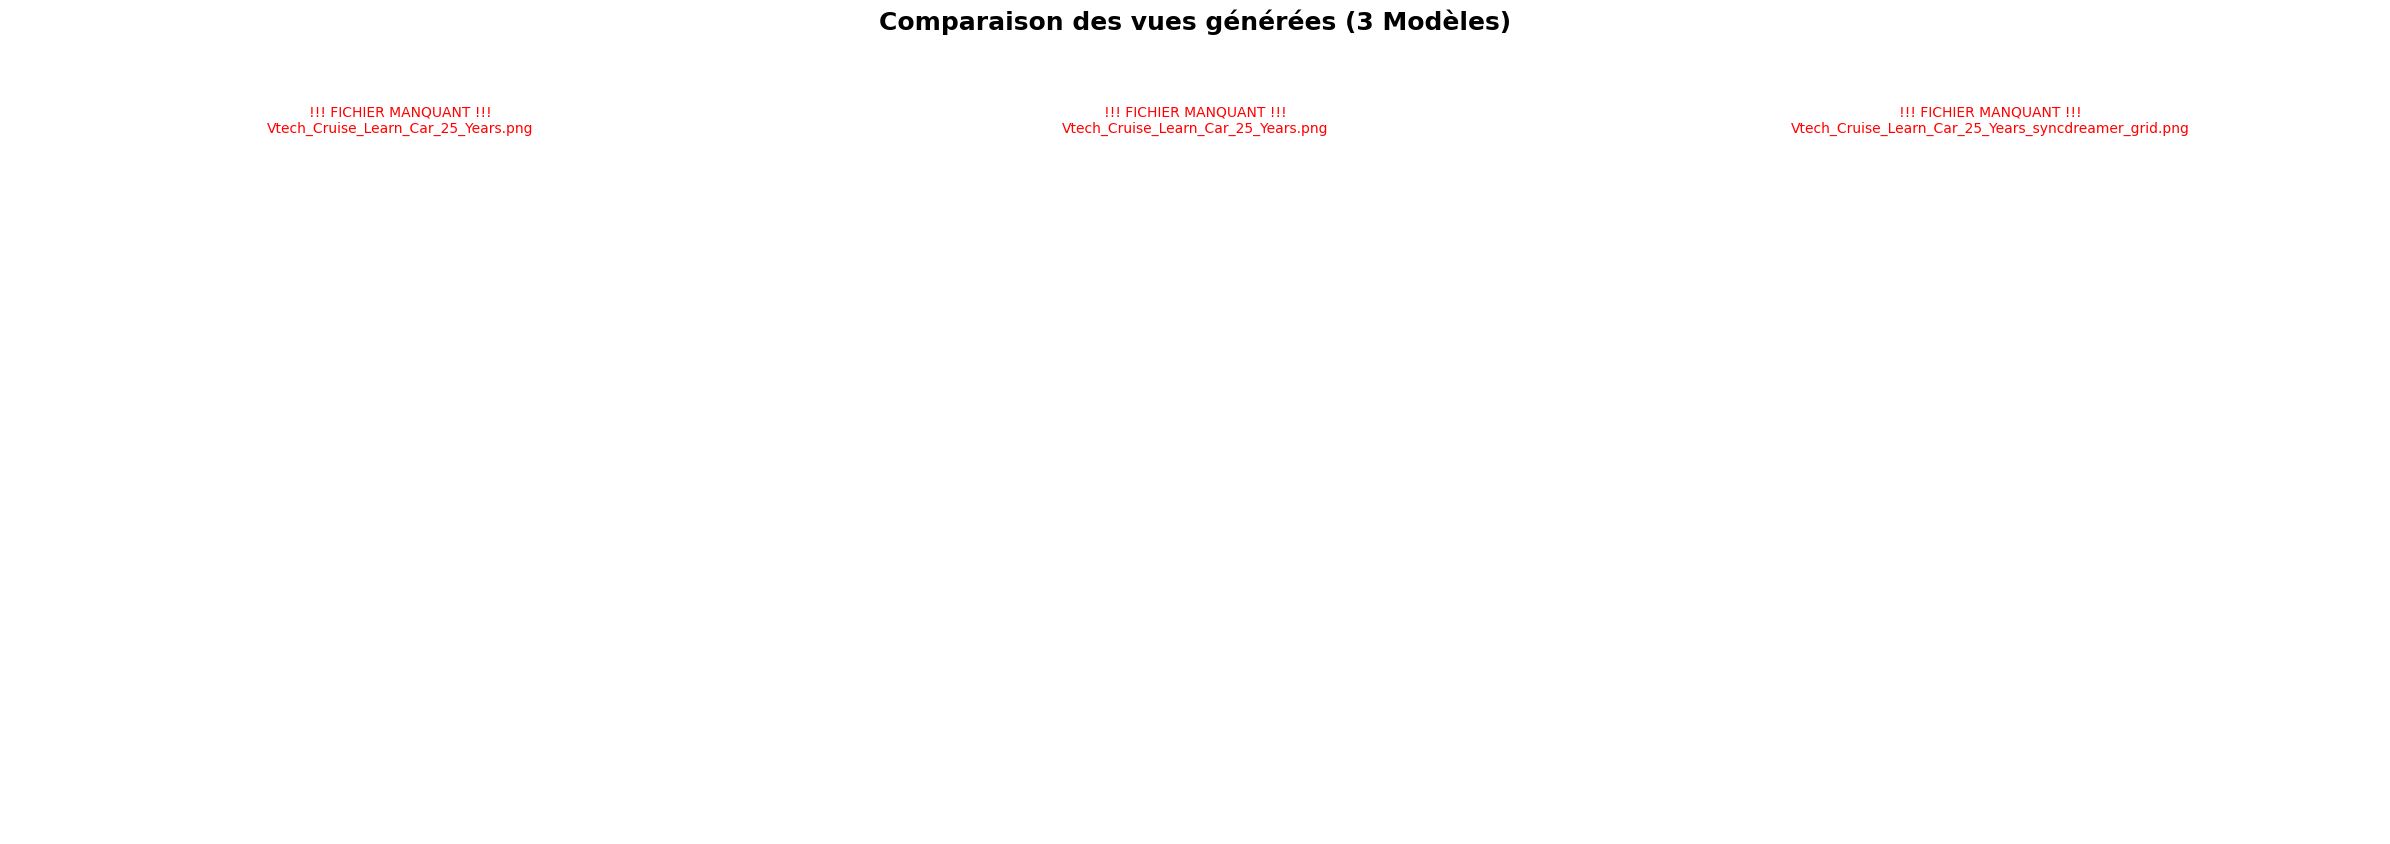


--- AFFICHAGE DES VIDÉOS POUR : Vtech_Cruise_Learn_Car_25_Years ---
[X] Vidéo manquante pour Original (Fine-tuned) : outputs/instant-mesh-base_zero123plus_finetuned/videos/Vtech_Cruise_Learn_Car_25_Years.mp4
[X] Vidéo manquante pour Option A (Base) : outputs/instant-mesh-base_zero123plus_base/videos/Vtech_Cruise_Learn_Car_25_Years.mp4
[X] Vidéo manquante pour Option B (SyncDreamer) : /content/InstantMesh/outputs/instant-mesh-base_syncdreamer/videos/Vtech_Cruise_Learn_Car_25_Years.mp4
Processing: Nintendo_Mario_Action_Figure.zip


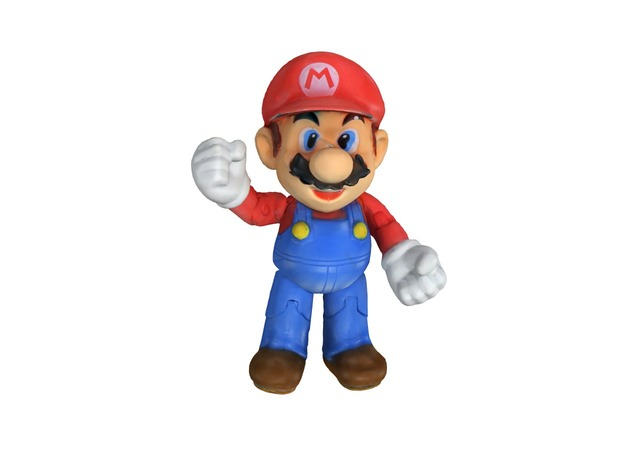

--- Lancement de l'inférence ---
Fichier : preview/Nintendo_Mario_Action_Figure/Nintendo_Mario_Action_Figure.jpg
Modèle : zero123plus_finetuned
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : preview/Nintendo_Mario_Action_Figure/Nintendo_Mario_Action_Figure.jpg
Modèle : zero123plus_base
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : /content/preview/Nintendo_Mario_Action_Figure/Nintendo_Mario_Action_Figure.jpg
Modèle : syncdreamer
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
Attention : Image absente -> outputs/instant-mesh-base_zero123plus_finetuned/images/Nintendo_Mario_Action_Figure.png
Attention 

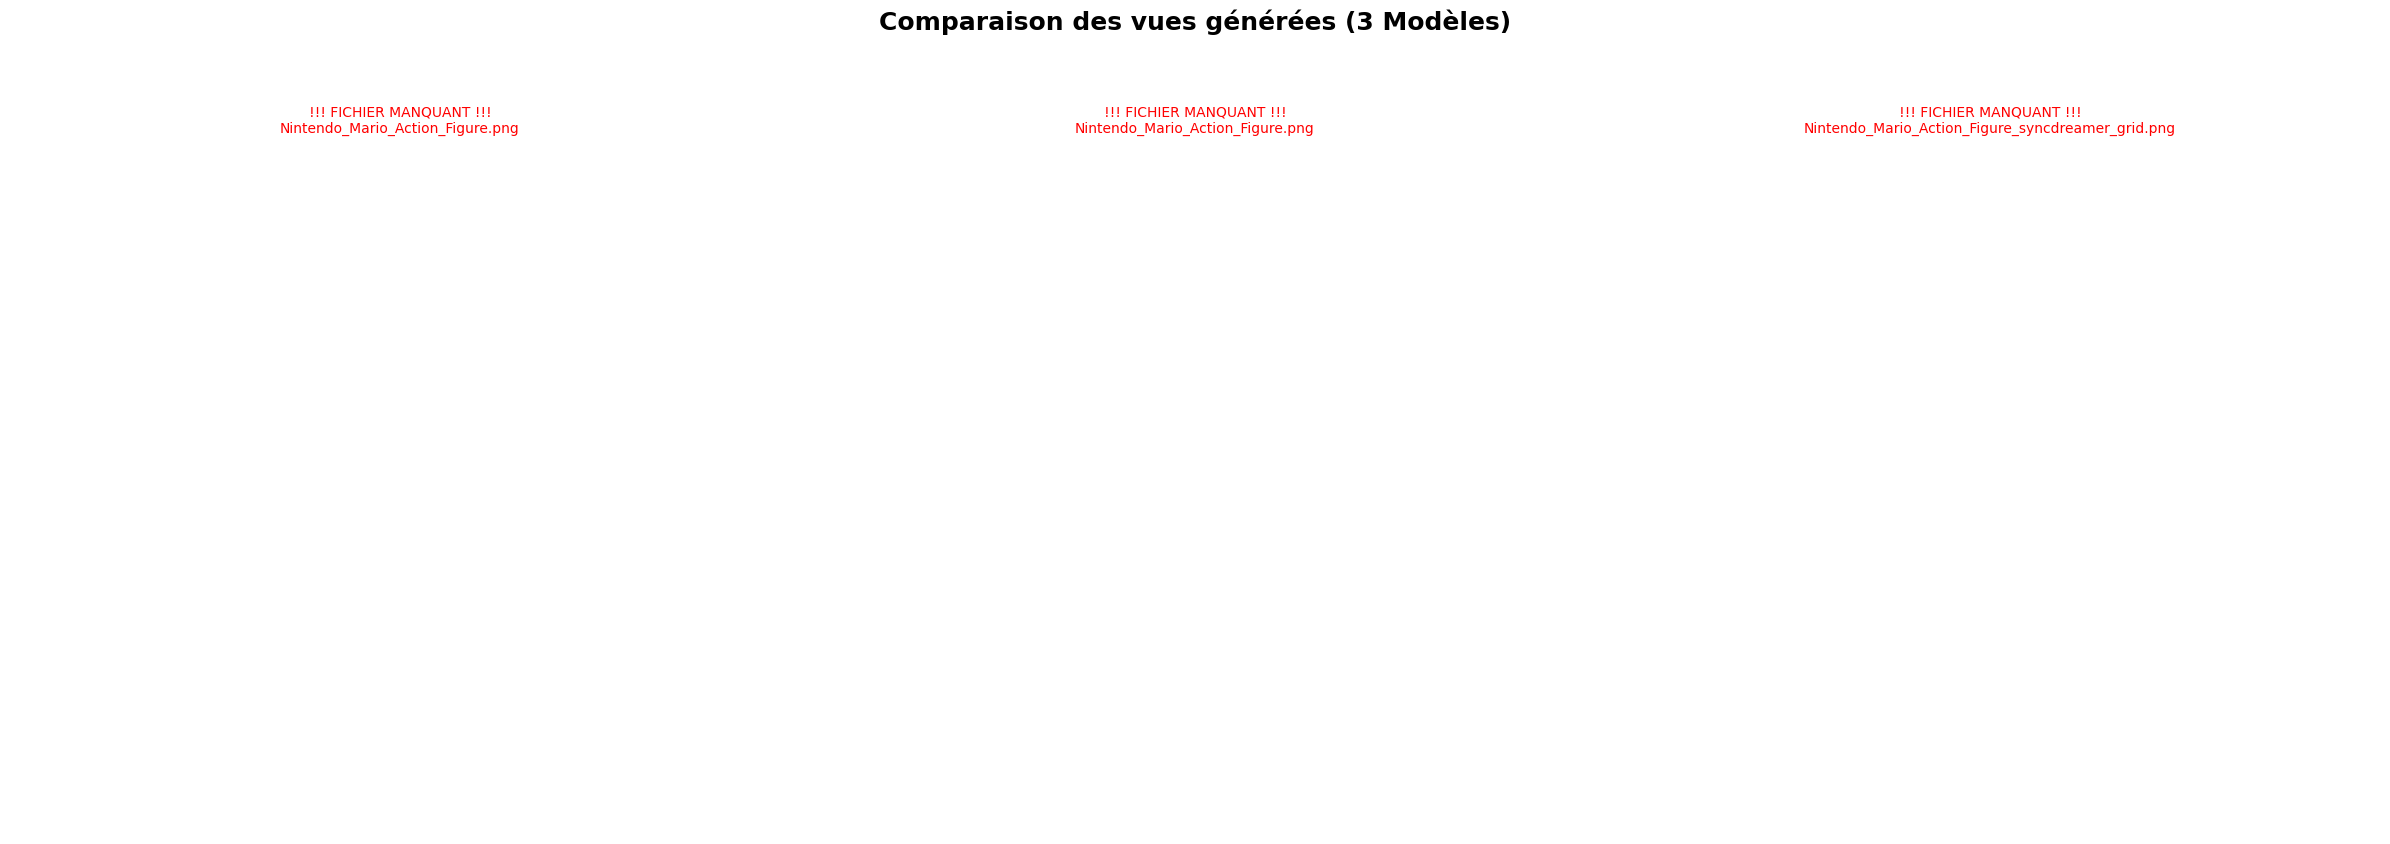


--- AFFICHAGE DES VIDÉOS POUR : Nintendo_Mario_Action_Figure ---
[X] Vidéo manquante pour Original (Fine-tuned) : outputs/instant-mesh-base_zero123plus_finetuned/videos/Nintendo_Mario_Action_Figure.mp4
[X] Vidéo manquante pour Option A (Base) : outputs/instant-mesh-base_zero123plus_base/videos/Nintendo_Mario_Action_Figure.mp4
[X] Vidéo manquante pour Option B (SyncDreamer) : /content/InstantMesh/outputs/instant-mesh-base_syncdreamer/videos/Nintendo_Mario_Action_Figure.mp4
Processing: VEGETABLE_GARDEN.zip


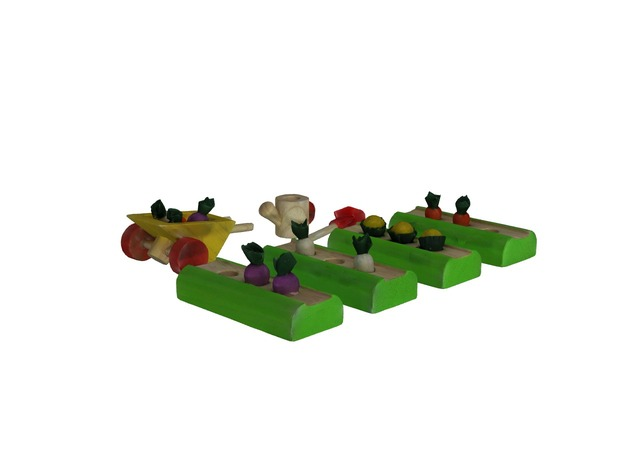

--- Lancement de l'inférence ---
Fichier : preview/VEGETABLE_GARDEN/VEGETABLE_GARDEN.jpg
Modèle : zero123plus_finetuned
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : preview/VEGETABLE_GARDEN/VEGETABLE_GARDEN.jpg
Modèle : zero123plus_base
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : /content/preview/VEGETABLE_GARDEN/VEGETABLE_GARDEN.jpg
Modèle : syncdreamer
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
Attention : Image absente -> outputs/instant-mesh-base_zero123plus_finetuned/images/VEGETABLE_GARDEN.png
Attention : Image absente -> outputs/instant-mesh-base_zero123plus_base/images/VEGETABLE_GARDE

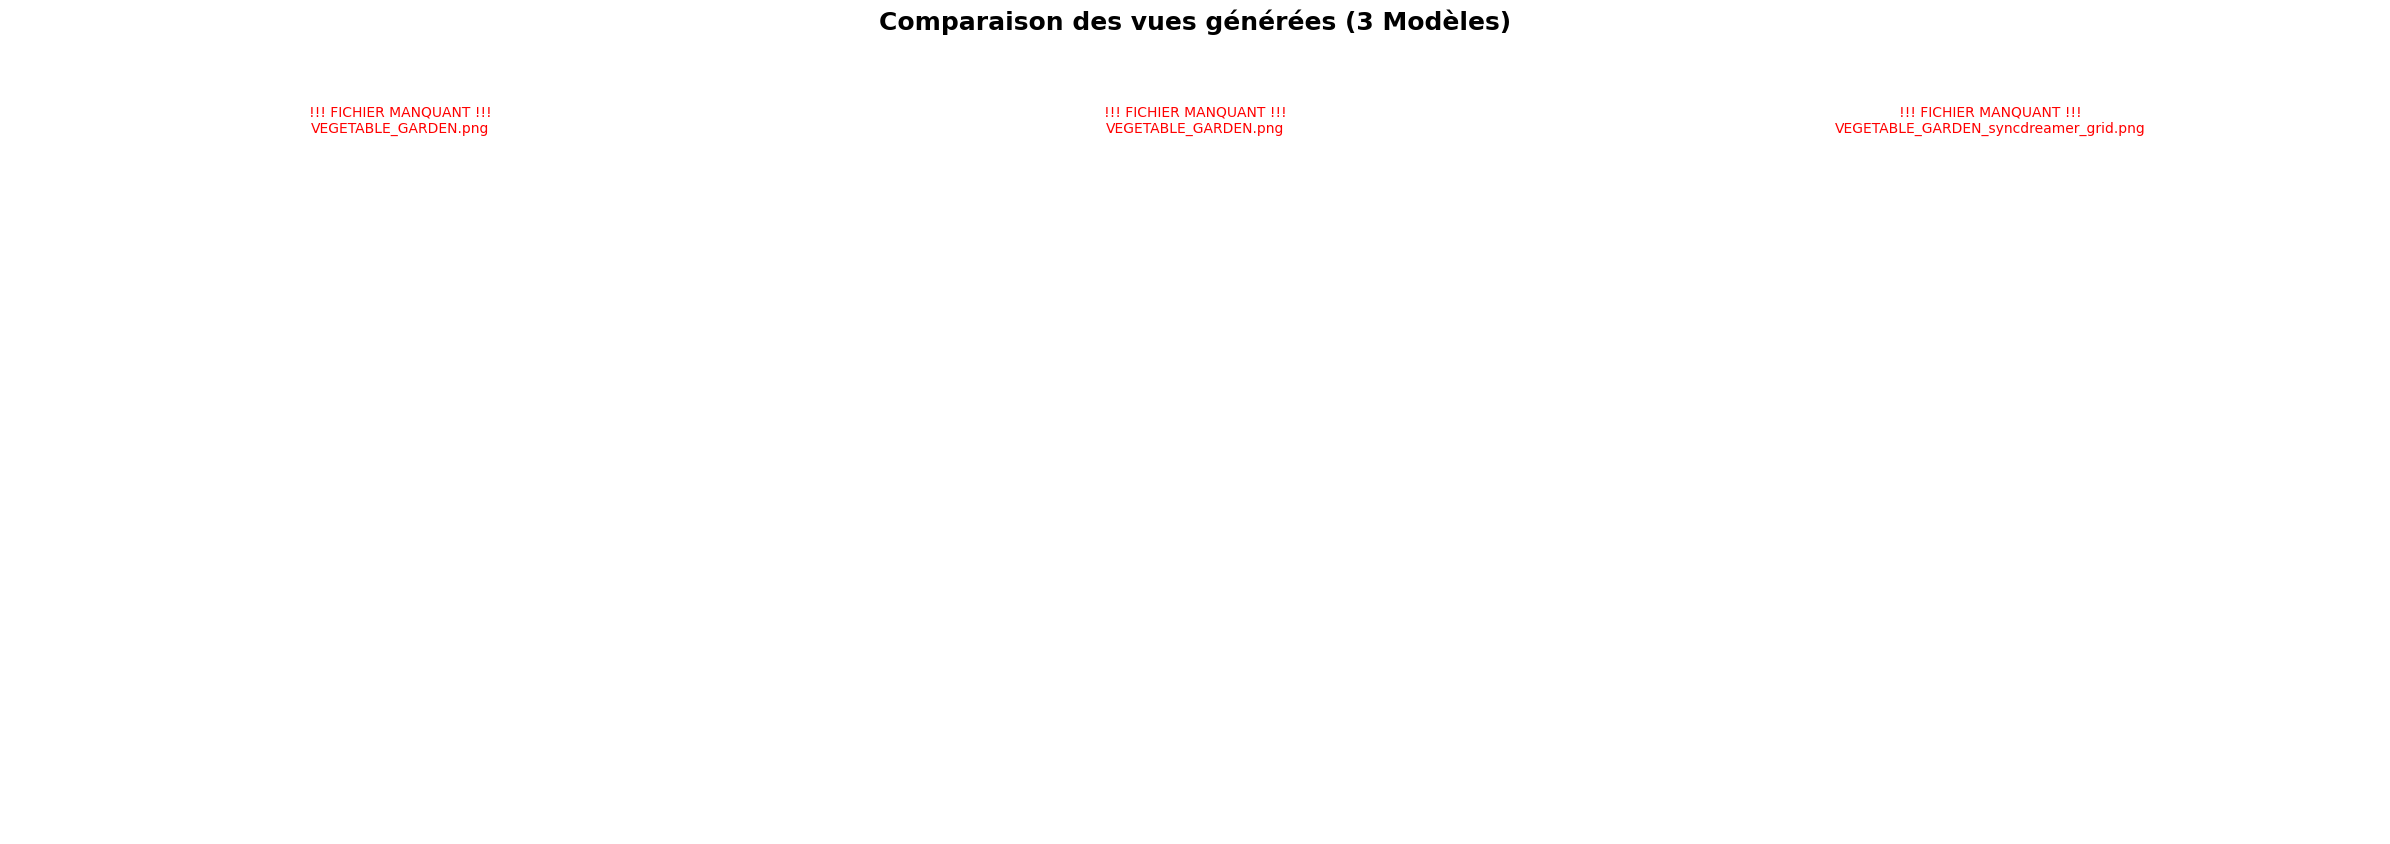


--- AFFICHAGE DES VIDÉOS POUR : VEGETABLE_GARDEN ---
[X] Vidéo manquante pour Original (Fine-tuned) : outputs/instant-mesh-base_zero123plus_finetuned/videos/VEGETABLE_GARDEN.mp4
[X] Vidéo manquante pour Option A (Base) : outputs/instant-mesh-base_zero123plus_base/videos/VEGETABLE_GARDEN.mp4
[X] Vidéo manquante pour Option B (SyncDreamer) : /content/InstantMesh/outputs/instant-mesh-base_syncdreamer/videos/VEGETABLE_GARDEN.mp4


In [26]:
import os
import subprocess
from pathlib import Path
import random as rd
from zipfile import ZipFile

GOOGLE_FOLDER = Path("/kaggle/working/Google_data")
GOOGLE_FOLDER.mkdir(parents=True, exist_ok=True)

for f in GOOGLE_FOLDER.glob("*.zip"):
    if f.stat().st_size < 1024:
        f.unlink()


OBJS = [
    "Nintendo_Mario_Action_Figure", 
    "VEGETABLE_GARDEN",
]

print(f"Téléchargement vers : {GOOGLE_FOLDER}...")

for obj_name in OBJS:
    zip_file = GOOGLE_FOLDER / f"{obj_name}.zip"
    
    if not zip_file.exists():
        # Nouvelle URL plus directe
        url = f"https://fuel.gazebosim.org/1.0/GoogleResearch/models/{obj_name}.zip"
        print(f"Tentative pour {obj_name}...", end=" ")
        
        # On ajoute -A (User-Agent) pour éviter d'être bloqué
        result = subprocess.run([
            "curl", "-L", "-A", "Mozilla/5.0", "-s", url, "-o", str(zip_file)
        ])
        
        if zip_file.exists() and zip_file.stat().st_size > 1024:
            print(f"({zip_file.stat().st_size // 1024} KB)")
        else:
            print("Échec (le fichier est vide ou l'URL est mauvaise)")
            if zip_file.exists(): zip_file.unlink() # On supprime le raté

def get_google_ref(path_to_ref: Path, random: bool = False):
    if not path_to_ref.exists(): return None, None
    try:
        with ZipFile(path_to_ref, mode="r") as z:
            namelist = z.namelist()
            images = sorted([p for p in namelist if p.lower().endswith((".jpg", ".png"))])
            objs = [p for p in namelist if p.lower().endswith(".obj")]
            if not images or not objs: return None, None
            return (rd.choice(images) if random else images[0]), objs[0]
    except:
        return None, None


valides = list(GOOGLE_FOLDER.glob("*.zip"))
print(f"\nPrêt ! {len(valides)} fichiers téléchargés dans {GOOGLE_FOLDER}")

In [ ]:
#TMP
OBJS = {
    "Weisshai_Great_White_Shark", "Vtech_Stack_Sing_Rings_636_Months",
    "Vtech_Roll_Learn_Turtle", "Vtech_Cruise_Learn_Car_25_Years",
    "Victor_Reversible_Bookend", "VEGETABLE_GARDEN",
    "TriStar_Products_PPC_Power_Pressure_Cooker_XL_in_Black",
    "Toysmith_Windem_Up_Flippin_Animals_Dog", "Threshold_Porcelain_Spoon_Rest_White",
    "TABLEWARE_SET_5ww1UFLuCJG", "TWIST_SHAPE", "TEA_SET", "TWISTED_PUZZLE",
    "TABLEWARE_SET_5CHkPjjxVpp", "TABLEWARE_SET", "Squirrel",
    "Sootheze_Cold_Therapy_Elephant", "Shark", "Sootheze_Toasty_Orca",
    "Schleich_Lion_Action_Figure", "Schleich_S_Bayala_Unicorn_70432",
    "Schleich_Spinosaurus_Action_Figure", "Schleich_Therizinosaurus_ln9cruulPqc",
    "Sonny_School_Bus", "Schleich_Hereford_Bull", "Schleich_Bald_Eagle",
    "Schleich_Allosaurus", "Schleich_African_Black_Rhino", "STEAK_SET",
    "STACKING_BEAR_V04KKgGBn2A", "STACKING_BEAR", "SORTING_TRAIN",
    "SORTING_BUS", "SHAPE_SORTER", "SHAPE_MATCHING_NxacpAY9jDt",
    "SHAPE_MATCHING", "SANDWICH_MEAL", "Rubbermaid_Large_Drainer",
    "Room_Essentials_Dish_Drainer_Collapsible_White",
    "Razer_Kraken_Pro_headset_Full_size_Black", "Remington_TStudio_Hair_Dryer",
    "Razer_Taipan_White_Ambidextrous_Gaming_Mouse",
    "Razer_BlackWidow_Stealth_2014_Keyboard_07VFzIVabgh", "Racoon",
    "ProSport_Harness_to_Booster_Seat", "PARENT_ROOM_FURNITURE_SET_1_DLKEy8H4mwK",
    "PUNCH_DROP", "POUNDING_MUSHROOMS", "Ortho_Forward_Facing_QCaor9ImJ2G",
    "Ortho_Forward_Facing_3Q6J2oKJD92", "Ortho_Forward_Facing",
    "Ocedar_Snap_On_Dust_Pan_And_Brush_1_ct", "OXO_Soft_Works_Can_Opener_SnapLock",
    "Object", "JA_Henckels_International_Premio_Cutlery_Block_Set_14Piece",
    "Great_Dinos_Triceratops_Toy", "Granimals_20_Wooden_ABC_Blocks_Wagon_g2TinmUGGHI",
    "FARM_ANIMAL", "Dino_5", "Dino_4", "Dino_3", "DANCING_ALLIGATOR_zoWBjc0jbTs",
    "Crosley_Alarm_Clock_Vintage_Metal", "CASTLE_BLOCKS", "Android_Lego",
    "Animal_Planet_Foam_2Headed_Dragon", "Transformers_Age_of_Extinction_Mega_1Step_Bumblebee_Figure",
    "Transformers_Age_of_Extinction_Stomp_and_Chomp_Grimlock_Figure",
    "Thomas_Friends_Wooden_Railway_Talking_Thomas_z7yi7UFHJRj",
    "Teenage_Mutant_Ninja_Turtles_Rahzar_Action_Figure", "Superman_Battle_of_Smallville",
    "Nintendo_Mario_Action_Figure", "Nintendo_Yoshi_Action_Figure",
    "My_Little_Pony_Princess_Celestia", "Lenovo_Yoga_2_11",
    "LEGO_Duplo_Build_and_Play_Box_4629", "LEGO_Duplo_Creative_Animals_10573",
    "LEGO_5887_Dino_Defense_HQ", "BlueBlack_Nintendo_3DSXL", "2_of_Jenga_Classic_Game"
}

In [ ]:
!ls -lrt /content/Google_data

Processing: Vtech_Cruise_Learn_Car_25_Years.zip


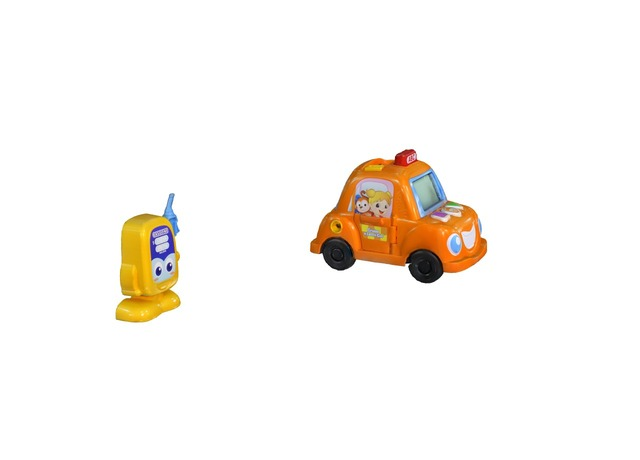

--- Lancement de l'inférence ---
Fichier : preview/Vtech_Cruise_Learn_Car_25_Years/Vtech_Cruise_Learn_Car_25_Years.jpg
Modèle : zero123plus_finetuned
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : preview/Vtech_Cruise_Learn_Car_25_Years/Vtech_Cruise_Learn_Car_25_Years.jpg
Modèle : zero123plus_base
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : /content/preview/Vtech_Cruise_Learn_Car_25_Years/Vtech_Cruise_Learn_Car_25_Years.jpg
Modèle : syncdreamer
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
Attention : Image absente -> outputs/instant-mesh-base_zero123plus_finetuned/images/Vtech_Cruise_Learn_Car_25

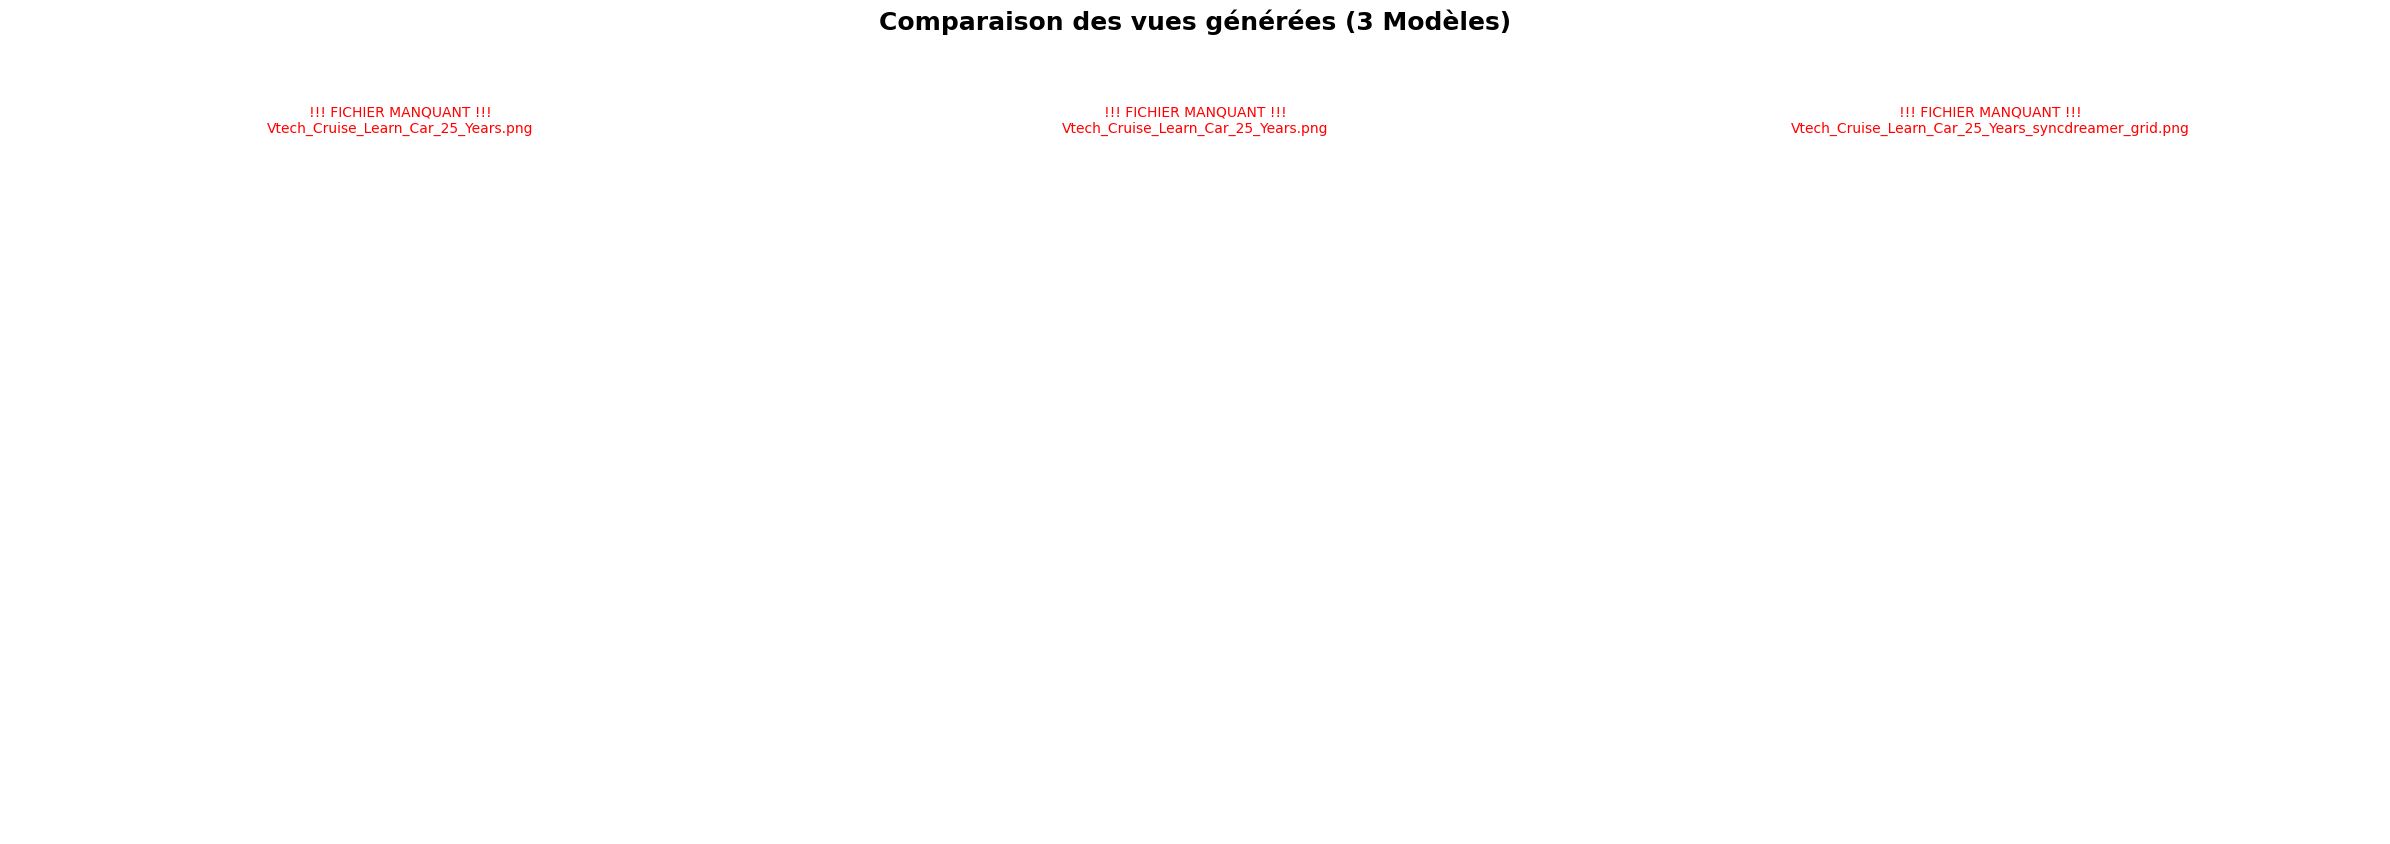


--- AFFICHAGE DES VIDÉOS POUR : Vtech_Cruise_Learn_Car_25_Years ---
[X] Vidéo manquante pour Original (Fine-tuned) : outputs/instant-mesh-base_zero123plus_finetuned/videos/Vtech_Cruise_Learn_Car_25_Years.mp4
[X] Vidéo manquante pour Option A (Base) : outputs/instant-mesh-base_zero123plus_base/videos/Vtech_Cruise_Learn_Car_25_Years.mp4
[X] Vidéo manquante pour Option B (SyncDreamer) : /content/InstantMesh/outputs/instant-mesh-base_syncdreamer/videos/Vtech_Cruise_Learn_Car_25_Years.mp4
Processing: Nintendo_Mario_Action_Figure.zip


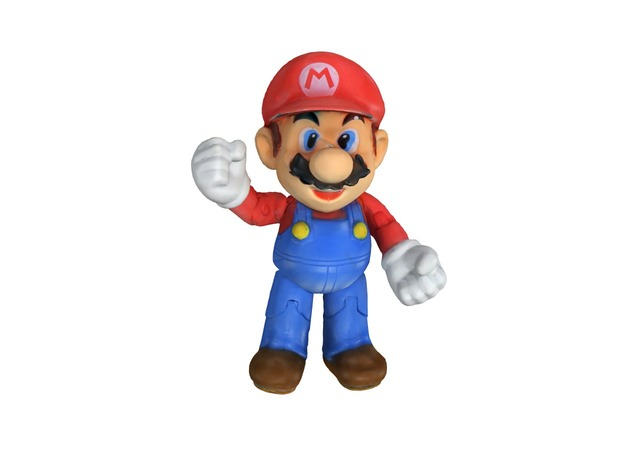

--- Lancement de l'inférence ---
Fichier : preview/Nintendo_Mario_Action_Figure/Nintendo_Mario_Action_Figure.jpg
Modèle : zero123plus_finetuned
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : preview/Nintendo_Mario_Action_Figure/Nintendo_Mario_Action_Figure.jpg
Modèle : zero123plus_base
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : /content/preview/Nintendo_Mario_Action_Figure/Nintendo_Mario_Action_Figure.jpg
Modèle : syncdreamer
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
Attention : Image absente -> outputs/instant-mesh-base_zero123plus_finetuned/images/Nintendo_Mario_Action_Figure.png
Attention 

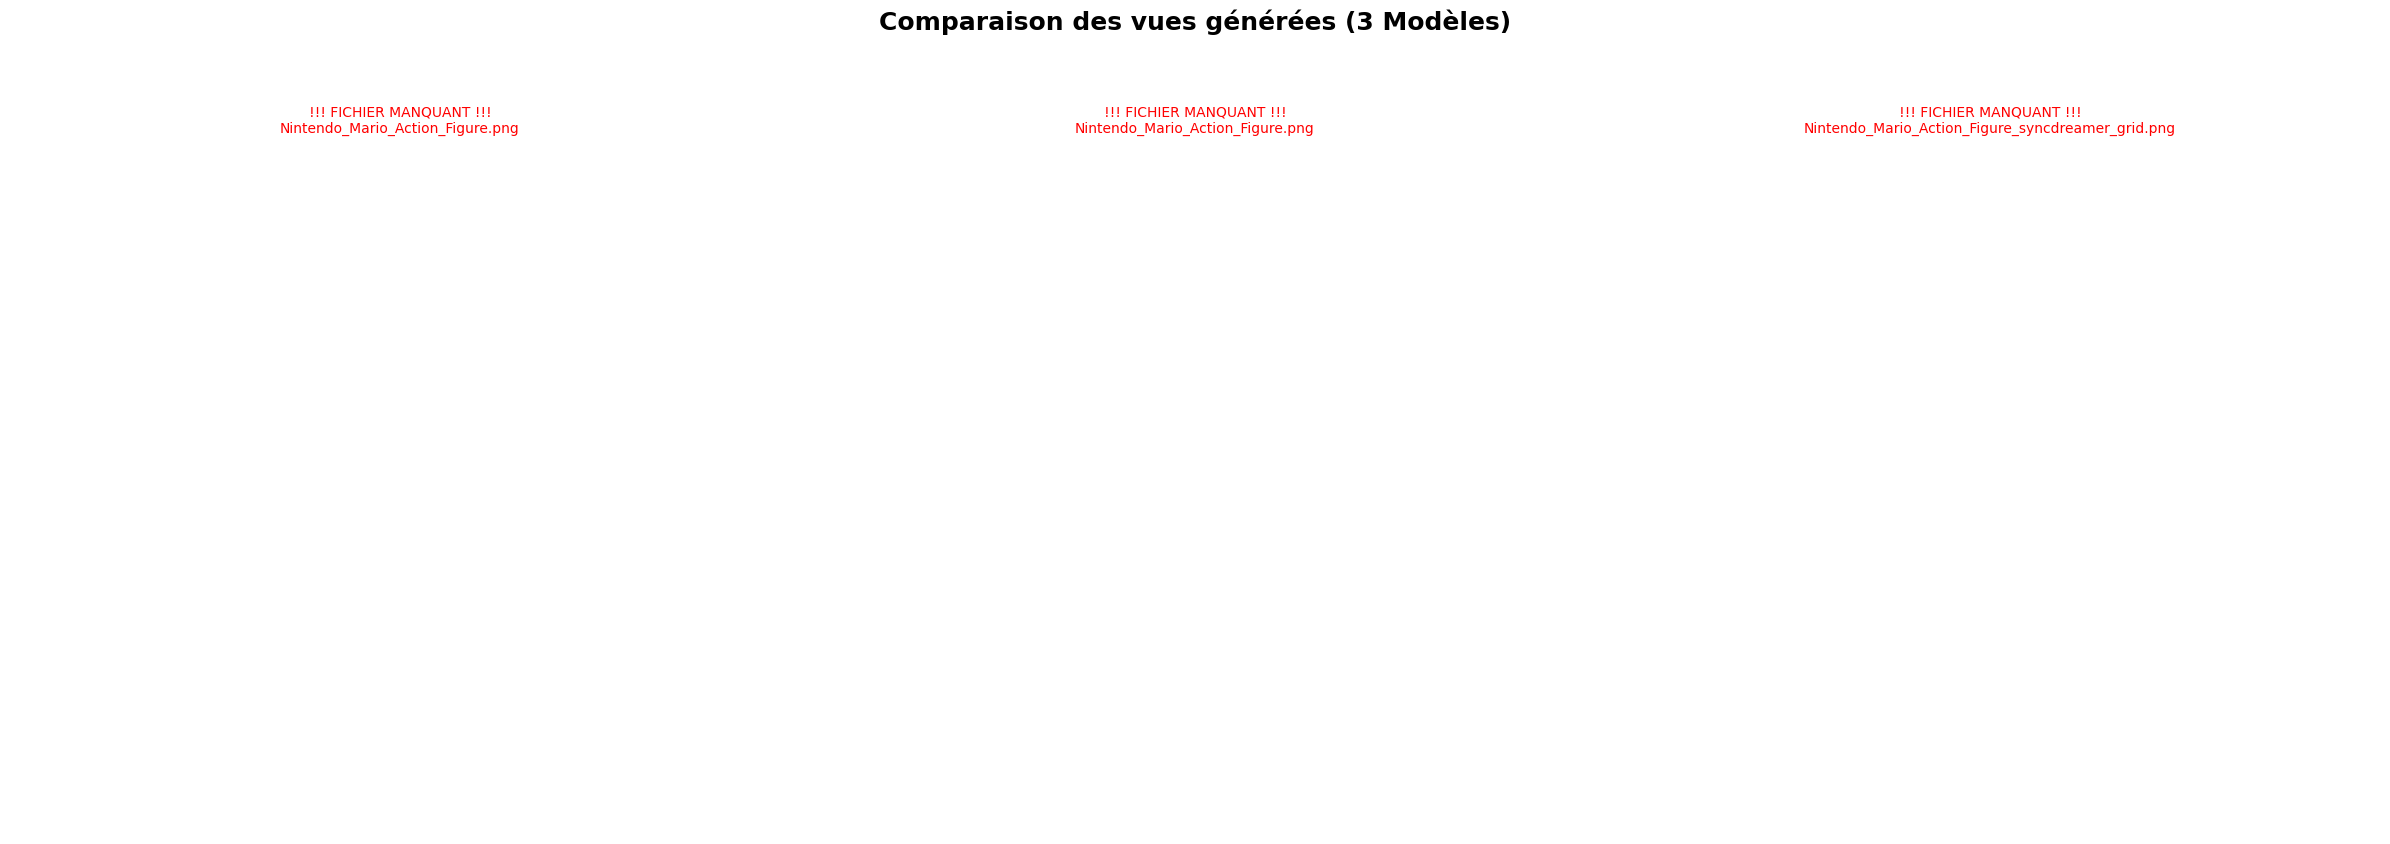


--- AFFICHAGE DES VIDÉOS POUR : Nintendo_Mario_Action_Figure ---
[X] Vidéo manquante pour Original (Fine-tuned) : outputs/instant-mesh-base_zero123plus_finetuned/videos/Nintendo_Mario_Action_Figure.mp4
[X] Vidéo manquante pour Option A (Base) : outputs/instant-mesh-base_zero123plus_base/videos/Nintendo_Mario_Action_Figure.mp4
[X] Vidéo manquante pour Option B (SyncDreamer) : /content/InstantMesh/outputs/instant-mesh-base_syncdreamer/videos/Nintendo_Mario_Action_Figure.mp4
Processing: VEGETABLE_GARDEN.zip


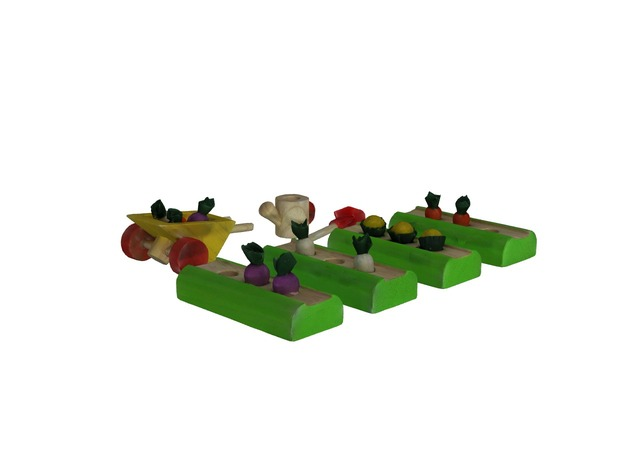

--- Lancement de l'inférence ---
Fichier : preview/VEGETABLE_GARDEN/VEGETABLE_GARDEN.jpg
Modèle : zero123plus_finetuned
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : preview/VEGETABLE_GARDEN/VEGETABLE_GARDEN.jpg
Modèle : zero123plus_base
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
--- Lancement de l'inférence ---
Fichier : /content/preview/VEGETABLE_GARDEN/VEGETABLE_GARDEN.jpg
Modèle : syncdreamer
[Errno 2] No such file or directory: '/content/InstantMesh'
/content
python3: can't open file '/content/run.py': [Errno 2] No such file or directory
Attention : Image absente -> outputs/instant-mesh-base_zero123plus_finetuned/images/VEGETABLE_GARDEN.png
Attention : Image absente -> outputs/instant-mesh-base_zero123plus_base/images/VEGETABLE_GARDE

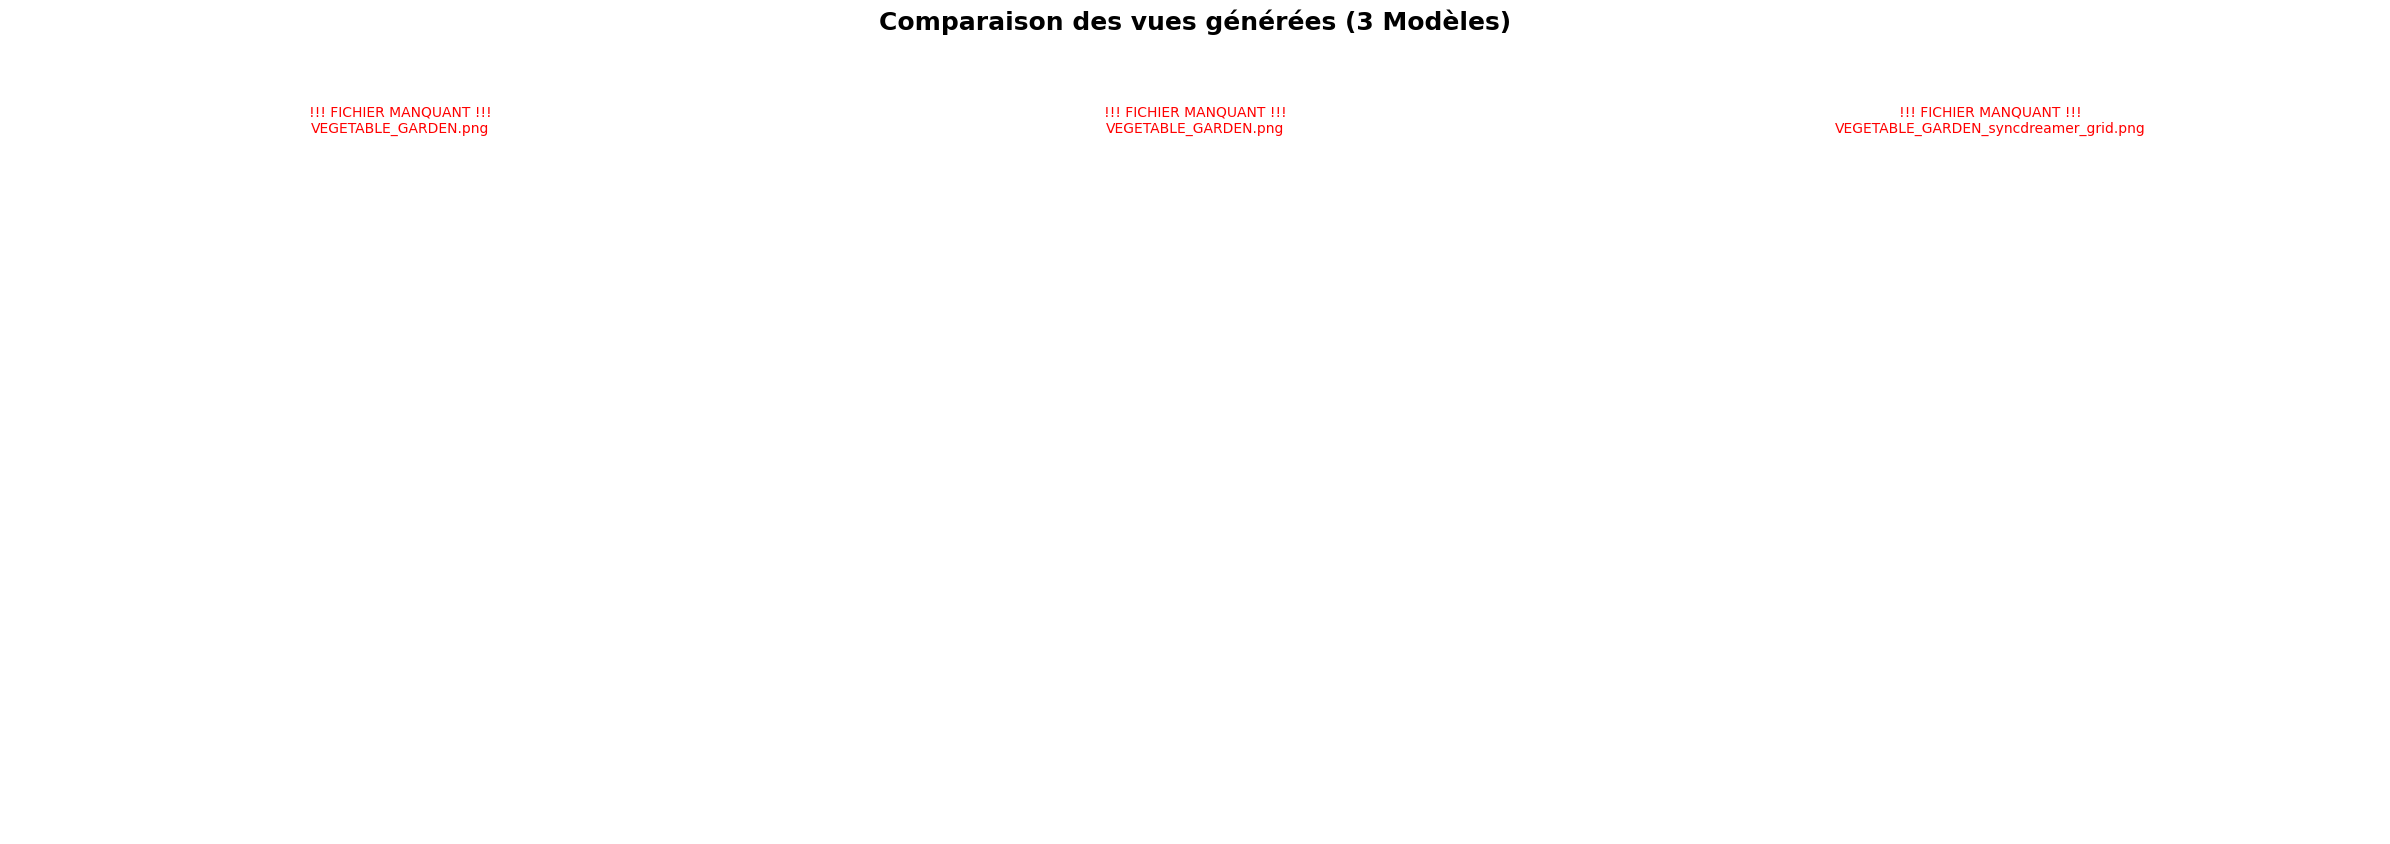


--- AFFICHAGE DES VIDÉOS POUR : VEGETABLE_GARDEN ---
[X] Vidéo manquante pour Original (Fine-tuned) : outputs/instant-mesh-base_zero123plus_finetuned/videos/VEGETABLE_GARDEN.mp4
[X] Vidéo manquante pour Option A (Base) : outputs/instant-mesh-base_zero123plus_base/videos/VEGETABLE_GARDEN.mp4
[X] Vidéo manquante pour Option B (SyncDreamer) : /content/InstantMesh/outputs/instant-mesh-base_syncdreamer/videos/VEGETABLE_GARDEN.mp4


In [27]:
import os
from IPython.display import Image as DisplayImage, display
from zipfile import ZipFile

source_folder = "/kaggle/working/Google_data"
temp_preview_dir = "preview"

zip_files = [f for f in os.listdir(source_folder) if f.endswith('.zip')]

if zip_files:
    for zip_name in zip_files:
        target_zip = os.path.join(source_folder, zip_name)
        zip_id = os.path.splitext(zip_name)[0]
        
        print(f"Processing: {zip_name}")

        with ZipFile(target_zip, 'r') as z:
            # On cherche spécifiquement dans le dossier thumbnails
            images = sorted([f for f in z.namelist() if "thumbnails" in f.lower() and f.lower().endswith(('.jpg', '.png'))])
            
            # Si thumbnails est vide, on cherche une image qui n'est pas une texture
            if not images:
                images = sorted([f for f in z.namelist() if f.lower().endswith(('.jpg', '.png')) and "texture" not in f.lower()])
            
            if not images:
                print(f"No valid image found in {zip_name}")
                continue
            
            first_image = images[0]
            extraction_path = os.path.join(temp_preview_dir, zip_id)
            z.extract(first_image, extraction_path)
            
            full_img_path = os.path.join(extraction_path, first_image)
            unique_img_path = os.path.join(extraction_path, f"{zip_id}.jpg")
            
            # Gestion du renommage même si le fichier est dans un sous-dossier extrait
            os.rename(full_img_path, unique_img_path)
            
            display(DisplayImage(filename=unique_img_path, width=200))
            
            executer_inference_3d(filename=unique_img_path, model_type="zero123plus_finetuned")
            executer_inference_3d(filename=unique_img_path, model_type="zero123plus_base")
            
            chemin_complet = os.path.abspath(unique_img_path)
            executer_inference_3d(filename=chemin_complet, model_type="syncdreamer")
            
            comparer_modeles_3d(filename=zip_id)

    # !rm -rf preview
else:
    print(f"No ZIP files found in {source_folder}")

In [ ]:
import shutil
import os

path = '/kaggle/working/Google_data'

if os.path.exists(path):
    shutil.rmtree(path)
    print(f"Le dossier {path} a été supprimé.")
else:
    print("Le dossier n'existe pas.")